In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import xarray as xr
from numpy.typing import NDArray
from scipy.stats import distributions

In [2]:
FIG_SAVE_FMT = "png"

In [3]:
NOTEBOOK_DIR = Path().cwd().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
INNER_NITRATE_PATH = (
    DATA_DIR / "CE01ISSP/CE01ISSP_nitrate_binned_baseline_subtracted_2014-04-17_2025-07-26_with_dndt_resampled.nc"
)
MIDSHELF_NITRATE_PATH = (
    DATA_DIR / "CE02SHSP/CE02SHSP_nitrate_binned_baseline_subtracted_2015-03-18_2024-09-15_with_dndt_resampled.nc"
)
WIND_PATH = DATA_DIR / "NDBC_46050/46050_wind_binned_with_w5d_w8d.nc"
VEL_PATH = DATA_DIR / "NH10_Mooring_Data/nh10_hourly_data_1997_2024_rotated_filtered_streamwise_v5.2.nc"
GEBCO_PATH = list(Path(DATA_DIR / "GEBCO/").glob("*.nc"))

VELOCITY_VARIABLE = (
    "cs_proj"  # cs for cross-shelf with depth mean subtraced; cs_proj for cross-shelf projected by McCabe et al 2015
)

In [4]:
def calculate_budget_volume(
    da: xr.DataArray,
    d_min: float,
    d_max: float,
    d_step: float,
    lon_min: float,
    lon_max: float,
    lat: float,
) -> xr.DataArray:
    """Calculate the volume of a control volume on the NHL.

    Args:
        da (xr.DataArray): DataArray with dimensions (time, distance_from_shore, lat, lon).
        d_min (float): Minimum depth in meters.
        d_max (float): Maximum depth in meters.
        d_step (float): Depth step in meters.
        lon_min (float): Minimum longitude of the control volume.
        lon_max (float): Maximum longitude of the control volume.
        lat (float): Latitude of the control volume.

    Returns:
        xr.DataArray: DataArray with the volume of the control volume at each time step.


    """
    bathymetry = xr.open_mfdataset(GEBCO_PATH).interp(lat=lat).interp({"lon": np.linspace(lon_min, lon_max, int(1e6))})
    coast = bathymetry.isel({"lon": np.nanargmin(np.abs(bathymetry.elevation.values))})

    bathymetry["distance_from_shore"] = xr.apply_ufunc(
        lambda x: haversine(
            bathymetry.lon[0].values,
            coast.lat.values,
            x,
            coast.lat.values,
        )
        - haversine(
            bathymetry.lon[0].values,
            coast.lat.values,
            coast.lon.values,
            coast.lat.values,
        ),
        bathymetry.lon,
    )
    bathymetry = bathymetry.swap_dims({"lon": "distance_from_shore"}).load()
    elevation = bathymetry.interp(
        distance_from_shore=np.arange(d_min, d_max, d_step),
        method="linear",
    )["elevation"]  # convert to m
    out = -elevation * d_step * da * 1000
    out = out.sum(dim="distance_from_shore")
    return out


def haversine(lon1: float, lat1: float, lon2: float, lat2: float) -> float:
    """Calculate the great circle distance between two points on the earth (specified in decimal degrees).

    Args:
        lon1 (scalar): longitude of first point
        lat1 (scalar): latitude of first point
        lon2 (scalar): longitude of second point
        lat2 (scalar): latitude of second point

    Returns:
        scalar: distance in km between (lon1, lat1) and (lon2, lat2)

    """
    # convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    # Radius of earth in kilometers is 6371
    km = 6371 * c
    return km

In [5]:
inner_nitrate = xr.open_dataset(INNER_NITRATE_PATH)
midshelf_nitrate = xr.open_dataset(MIDSHELF_NITRATE_PATH)
wind = xr.open_dataset(WIND_PATH, decode_timedelta=True)
velocity = xr.open_dataset(VEL_PATH).resample(time="1D").mean()

# calculate monthly means for midshelf nitrate
midshelf_nitrate_monthly = xr.Dataset(
    {
        "mean": midshelf_nitrate.groupby("time.month").mean(dim="time", skipna=True)["nitrate"],
        "std": midshelf_nitrate.groupby("time.month").std(dim="time", skipna=True)["nitrate"],
        "count": midshelf_nitrate.groupby("time.month").count(dim="time")["nitrate"],
    },
)
midshelf_nitrate_monthly["ci"] = midshelf_nitrate_monthly["std"] / np.sqrt(5) * distributions.t(5 - 1).isf(0.025)

In [6]:
midshelf_nitrate

<xarray.Dataset> Size: 47MB
Dimensions:                                    (depth: 160, time: 3470)
Coordinates:
  * depth                                      (depth) float64 1kB 0.0 ... 79.5
  * time                                       (time) datetime64[ns] 28kB 201...
    lat                                        float64 8B ...
Data variables:
    nitrate                                    (time, depth) float64 4MB ...
    temperature                                (time, depth) float64 4MB ...
    salinity_corrected_nitrate_qartod_results  (time, depth) float32 2MB ...
    deployment                                 (time, depth) float64 4MB ...
    pressure                                   (time, depth) float64 4MB ...
    practical_salinity                         (time, depth) float64 4MB ...
    absolute_salinity                          (time, depth) float64 4MB ...
    conservative_temperature                   (time, depth) float64 4MB ...
    sigma_t                                    (time, depth) float64 4MB ...
    density                                    (time, depth) float64 4MB ...
    dndt                                       (time, depth) float64 4MB ...
    dndt_volume_integrated                     (time) float64 28kB ...
Attributes: (12/71)
    node:                               SP001
    comment:                            
    publisher_email:                    
    sourceUrl:                          http://oceanobservatories.org/
    collection_method:                  recovered_cspp
    stream:                             nutnr_j_cspp_instrument_recovered
    ...                                 ...
    geospatial_vertical_units:          meters
    geospatial_vertical_resolution:     0.1
    geospatial_vertical_positive:       down
    deployment:                         [ 1.          1.          1.00064475 ...
    created_by:                         make_nitrate_datasets.py
    created_on:                         2026-03-19 05:46:41

## "Normal" Cross-shelf Advective Flux Divergence Calculation

In [7]:
# take the mean u * N and multiply by midshelf depth
midshelf_nitrate_flux = (midshelf_nitrate.interp(depth=velocity["depth"])["nitrate"] * velocity["u_proj"]).mean(
    dim="depth",
) * 80
midshelf_nitrate_flux = midshelf_nitrate_flux.rename("cross_shelf_flux")
# make a dataarray of u_proj(z) * N(z) selected using the mean N(z) from each month
midshelf_nitrate_monthly_flux = xr.merge(
    [
        (
            velocity.where(velocity["time.month"] == month, drop=True)["u_proj"]
            * midshelf_nitrate_monthly["mean"].interp(depth=velocity["depth"]).sel(month=month)
        )
        .rename("cross_shelf_flux")
        .drop_vars("month")
        .mean(dim="depth")
        * 80
        for month in range(4, 10)
    ],
)["cross_shelf_flux"]

In [19]:
def lagged_correlation(
    a: xr.DataArray,
    b: xr.DataArray,
    lags: NDArray,
) -> tuple[NDArray, NDArray, NDArray]:
    """Positive lags for b leading a, negative lags for a leading b.

    Args:
        a (xr.DataArray): time series
        b (xr.DataArray): time series
        lags (NDArray): lags to calculate cross correlation

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]: tuple of correlation, conf. intervals, and data points for each lag

    """
    corr = np.full(lags.size, np.nan)
    confint = np.full((lags.size, 2), np.nan)
    n = np.full(lags.size, np.nan)
    for i, t in enumerate(lags):
        b_shift = b.shift(time=t)
        a_shift, b_shift = xr.align(a, b_shift)
        mask = ~np.isnan(a_shift) & ~np.isnan(b_shift)
        ccf = sm.tsa.ccf(
            a_shift[mask],
            b_shift[mask],
            adjusted=True,
            nlags=1,
            alpha=0.05,
        )
        corr[i] = ccf[0][0]
        confint[i] = ccf[1]
        n[i] = np.sum(mask)
    return corr, confint, n


def plot_correlations(
    lags: NDArray,
    corr: NDArray,
    confint: NDArray,
    n: NDArray,
    xlabel: str | None = None,
    ylabel: str | None = None,
) -> None:
    """Plot the correlations with confidence intervals. Designed for use with `lagged_correlation()`.

    Args:
        lags (NDArray): lags used for correlation
        corr (NDArray): correlation values
        confint (NDArray): confidence intervals for the correlations
        n (NDArray): number of data points used for each lag
        xlabel (str | None, optional): label for x-axis. Defaults to None.
        ylabel (str | None, optional): label for y-axis. Defaults to None.

    """
    n_eff = float(np.nanmean(n)) / 11
    alpha = 0.05
    rho_crit = float(
        np.sqrt(
            distributions.f.isf(alpha, 1, n_eff - 2) / (n_eff - 2 + distributions.f.isf(alpha, 1, n_eff - 2)),
        ),
    )
    print(f"Critical correlation coefficient for n_eff={n_eff:.1f} at alpha={alpha}: {rho_crit:.2f}")

    _fig, ax = plt.subplots()
    ax.plot(lags, corr, color="k", lw=2)
    ax.fill_between(
        lags,
        confint[:, 0],
        confint[:, 1],
        color="gray",
        alpha=0.5,
        label="95% CI",
    )
    ax.axhline(rho_crit, color="k", ls="--", lw=1)
    ax.axhline(-rho_crit, color="k", ls="--", lw=1)
    ax.set_xlabel(xlabel) if xlabel else None
    ax.set_ylabel(ylabel) if ylabel else None
    ax.legend()
    plt.show()

Critical correlation coefficient for n_eff=262.5 at alpha=0.05: 0.12


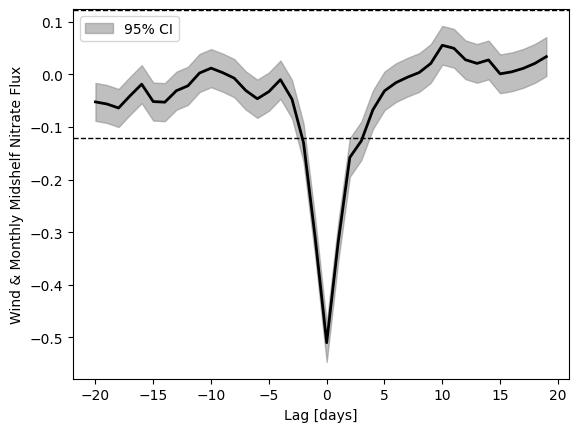

np.float64(-0.5099045288848163)

In [20]:
tdelay = np.arange(-20, 20)
correlation, confint, n = lagged_correlation(
    midshelf_nitrate_monthly_flux,
    wind["coare_y"],
    tdelay,
)

plot_correlations(
    tdelay,
    correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Wind & Monthly Midshelf Nitrate Flux",
)

correlation.min()

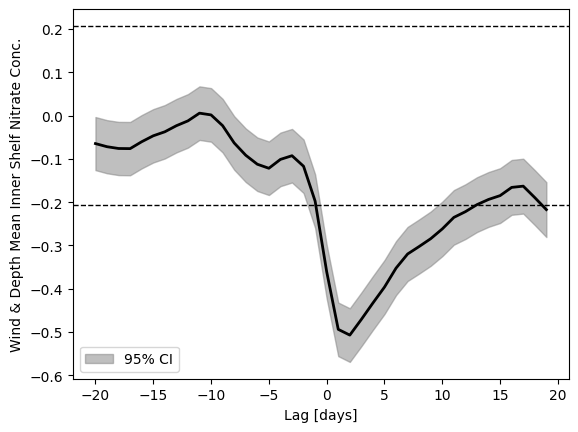

np.float64(-0.5070737380122062)

In [10]:
tdelay = np.arange(-20, 20)
correlation, confint, n = lagged_correlation(
    inner_nitrate.mean(dim="depth")["nitrate"],
    wind["coare_y"],
    tdelay,
)

plot_correlations(
    tdelay,
    correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Wind & Depth Mean Inner Shelf Nitrate Conc.",
)

correlation.min()

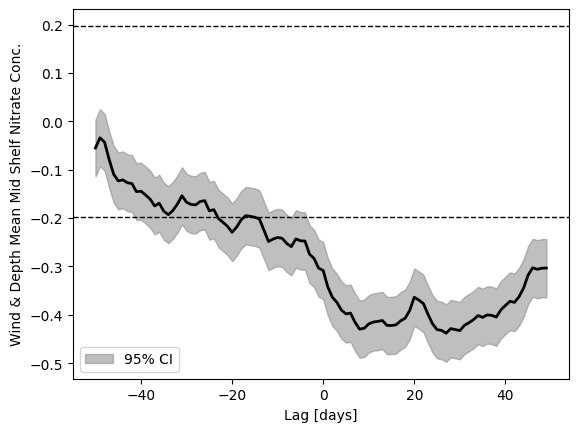

np.float64(-0.4378934223946533)

In [13]:
tdelay = np.arange(-50, 50)
correlation, confint, n = lagged_correlation(
    midshelf_nitrate.mean(dim="depth")["nitrate"],
    wind["coare_y"],
    tdelay,
)

plot_correlations(
    tdelay,
    correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Wind & Depth Mean Mid Shelf Nitrate Conc.",
)

correlation.min()

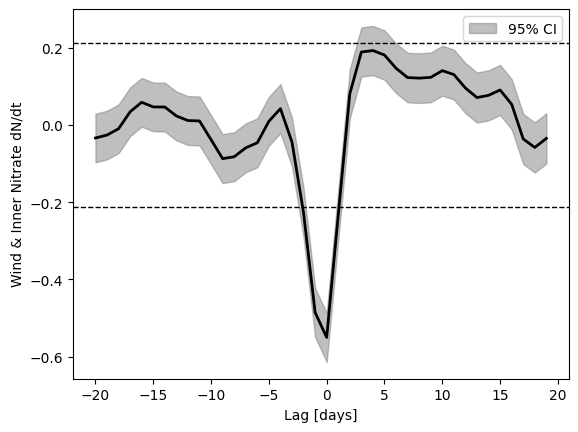

np.float64(-0.5502055949782667)

In [11]:
tdelay = np.arange(-20, 20)
correlation, confint, n = lagged_correlation(
    inner_nitrate["dndt_volume_integrated"],
    wind["coare_y"],
    tdelay,
)

plot_correlations(
    tdelay,
    correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Wind & Inner Nitrate dN/dt",
)

correlation.min()

Critical correlation coefficient for n_eff=87.4 at alpha=0.05: 0.21


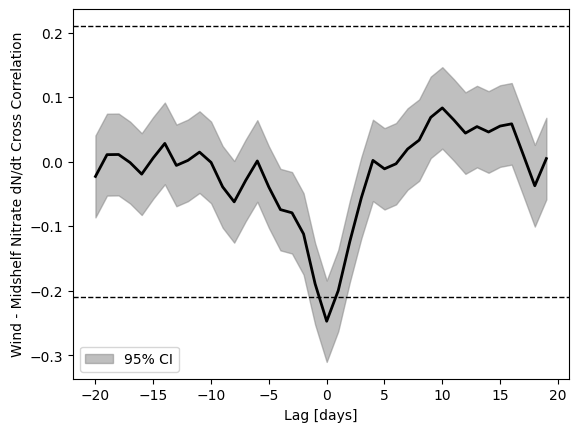

np.float64(-0.24742034763515175)

In [21]:
tdelay = np.arange(-20, 20)
correlation, confint, n = lagged_correlation(
    midshelf_nitrate["dndt_volume_integrated"],
    wind["coare_y"],
    tdelay,
)

plot_correlations(
    tdelay,
    correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Wind - Midshelf Nitrate dN/dt Cross Correlation",
)

correlation.min()

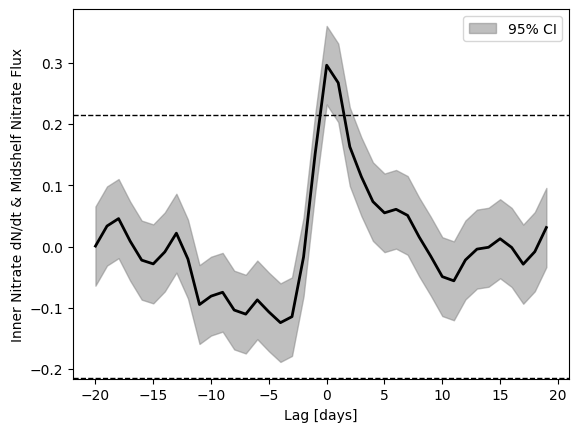

np.float64(0.2962461776044192)

In [13]:
flux_al_inner, inner_al_flux = xr.align(
    midshelf_nitrate_monthly_flux,
    inner_nitrate["dndt_volume_integrated"],
)

correlation, confint, n = lagged_correlation(
    flux_al_inner,
    inner_al_flux,
    tdelay,
)

plot_correlations(
    tdelay,
    correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Inner Nitrate dN/dt & Midshelf Nitrate Flux",
)

correlation.max()

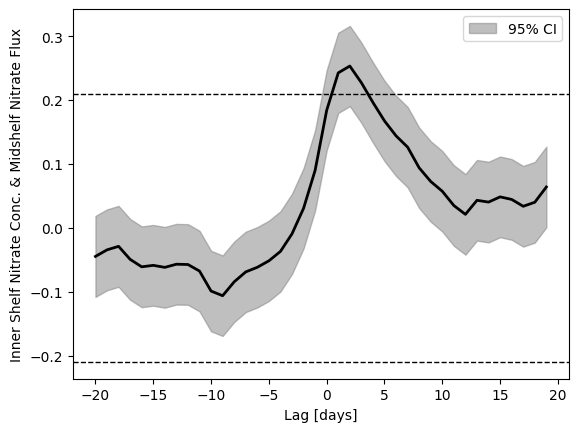

In [14]:
correlation, confint, n = lagged_correlation(
    inner_nitrate["nitrate"].mean(dim="depth"),
    midshelf_nitrate_monthly_flux,
    tdelay,
)

plot_correlations(
    tdelay,
    correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Inner Shelf Nitrate Conc. & Midshelf Nitrate Flux",
)

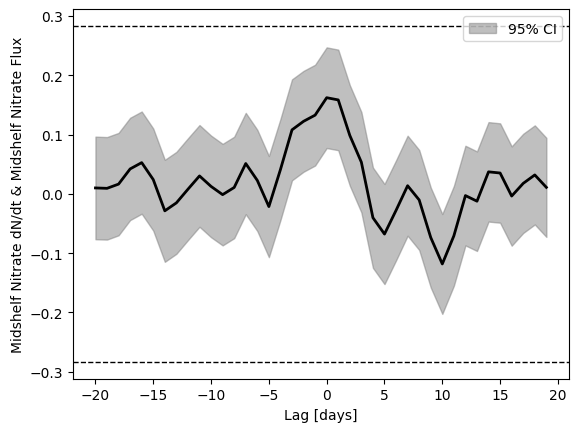

In [15]:
correlation, confint, n = lagged_correlation(
    midshelf_nitrate["dndt_volume_integrated"],
    midshelf_nitrate_monthly_flux,
    tdelay,
)

plot_correlations(
    tdelay,
    correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Midshelf Nitrate dN/dt & Midshelf Nitrate Flux",
)

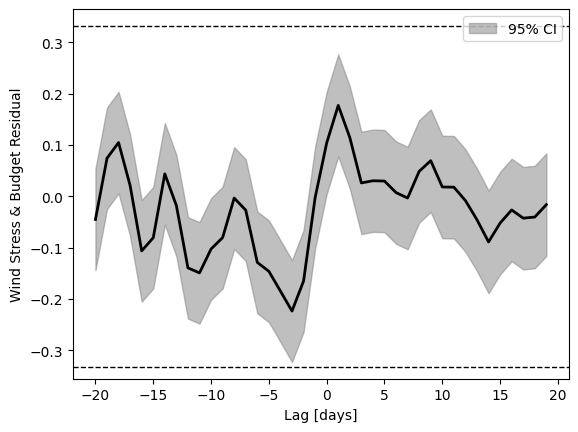

In [16]:
flux_al_nitr, inner_al_flux, mid_al_flux = xr.align(
    midshelf_nitrate_monthly_flux,
    inner_nitrate["dndt_volume_integrated"],
    midshelf_nitrate["dndt_volume_integrated"],
)

correlation, confint, n = lagged_correlation(
    wind.coare_y,
    (flux_al_nitr - inner_al_flux - mid_al_flux),
    tdelay,
)

plot_correlations(
    tdelay,
    correlation,
    confint,
    n,
    xlabel="Lag [days]",
    ylabel="Wind Stress & Budget Residual",
)

In [18]:
# correlation between nitrate flux calculated using in situ vs monthly mean mid shelf nitrate
flux_al_monthly_flux, monthly_flux_al_flux = xr.align(
    midshelf_nitrate_flux,
    midshelf_nitrate_monthly_flux,
)
mask = ~np.isnan(flux_al_monthly_flux) & ~np.isnan(monthly_flux_al_flux)
print(
    f"Correlation coefficient between nitrate fluxes: {xr.corr(flux_al_monthly_flux[mask], monthly_flux_al_flux[mask]).values:.2f}",
)
n_eff = len(flux_al_monthly_flux[mask]) / 11
alpha = 0.05
rho_crit = float(
    np.sqrt(
        distributions.f.isf(alpha, 1, n_eff - 2) / (n_eff - 2 + distributions.f.isf(alpha, 1, n_eff - 2)),
    ),
)
print(f"Critical correlation coefficient for n_eff={n_eff:.1f} at alpha={alpha}: {rho_crit:.2f}")

Correlation coefficient between nitrate fluxes: 0.94
Critical correlation coefficient for n_eff=52.5 at alpha=0.05: 0.27


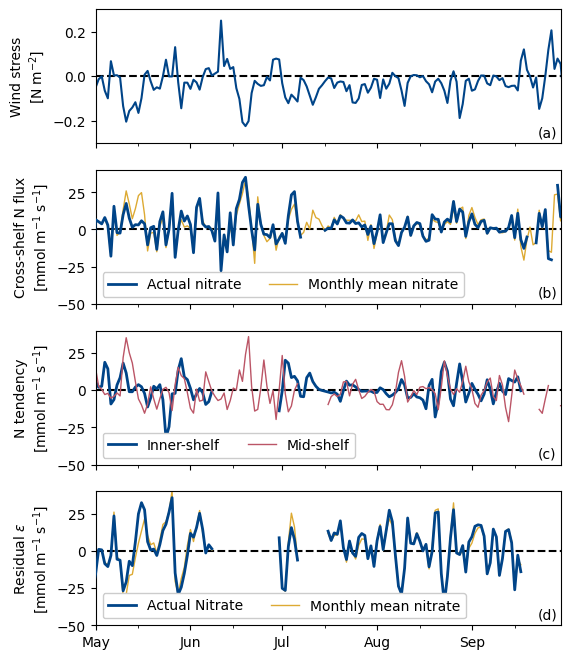

In [18]:
fig, axs = plt.subplots(4, 1, sharex=True, figsize=(6, 8))
axs[0].set_xlim(np.datetime64("2021-05-01"), np.datetime64("2021-09-30"))

axs[0].axhline(0, ls="--", color="black")
axs[0].plot(wind["time"], wind["coare_y"], color="#004488")
axs[0].set_ylim(-0.3, 0.3)
axs[0].set_ylabel("Wind stress\n[$\\mathsf{N \\; m^{-2}}$]")


axs[1].axhline(0, ls="--", color="black")
axs[1].plot(
    midshelf_nitrate_flux["time"],
    midshelf_nitrate_flux,
    label="Actual nitrate",
    color="#004488",
    linewidth=2,
    zorder=10,
)
axs[1].plot(
    midshelf_nitrate_monthly_flux["time"],
    midshelf_nitrate_monthly_flux,
    label="Monthly mean nitrate",
    color="#DDAA33",
    linewidth=1,
)
axs[1].set_ylim(-50, 40)
axs[1].set_ylabel("Cross-shelf N flux\n[$\\mathsf{mmol \\; m^{-1} \\; s^{-1}}$]")
axs[1].legend(facecolor="white", frameon=True, framealpha=1, ncols=2, loc="lower left")

axs[2].axhline(0, ls="--", color="black")
axs[2].plot(
    inner_nitrate["time"],
    inner_nitrate["dndt_volume_integrated"],
    color="#004488",
    label="Inner-shelf",
    linewidth=2,
)
axs[2].plot(
    midshelf_nitrate["time"],
    midshelf_nitrate["dndt_volume_integrated"],
    c="#BB5566",
    label="Mid-shelf",
    linewidth=1,
)
axs[2].set_ylim(-50, 40)
axs[2].set_ylabel("N tendency\n[$\\mathsf{mmol \\; m^{-1} \\; s^{-1}}$]")
axs[2].legend(facecolor="white", frameon=True, framealpha=1, ncols=2, loc="lower left")


axs[3].axhline(0, ls="--", color="black")
monthly_flux_al_nitr, inner_al_monthly_flux, mid_al_monthly_flux = xr.align(
    midshelf_nitrate_monthly_flux,
    inner_nitrate["dndt_volume_integrated"],
    midshelf_nitrate["dndt_volume_integrated"],
)
axs[3].plot(
    monthly_flux_al_nitr["time"],
    (monthly_flux_al_nitr - inner_al_monthly_flux - mid_al_monthly_flux),
    label="Actual Nitrate",
    color="#004488",
    linewidth=2,
    zorder=3,
)
flux_al_nitr, inner_al_flux, mid_al_flux = xr.align(
    midshelf_nitrate_flux,
    inner_nitrate["dndt_volume_integrated"],
    midshelf_nitrate["dndt_volume_integrated"],
)
axs[3].plot(
    flux_al_nitr["time"],
    (flux_al_nitr - inner_al_flux - mid_al_flux),
    label="Monthly mean nitrate",
    color="#DDAA33",
    linewidth=1,
)

axs[3].set_ylim(-50, 40)
axs[3].set_ylabel("Residual $\\epsilon$\n[$\\mathsf{mmol \\; m^{-1} \\; s^{-1}}$]")
axs[3].legend(facecolor="white", frameon=True, framealpha=1, ncols=2, loc="lower left")
axs[3].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axs[3].xaxis.set_major_locator(mdates.MonthLocator())
axs[3].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=15))


axs[0].annotate("(a)", xy=(0.95, 0.05), xycoords="axes fraction", fontsize=10)
axs[1].annotate("(b)", xy=(0.95, 0.05), xycoords="axes fraction", fontsize=10)
axs[2].annotate("(c)", xy=(0.95, 0.05), xycoords="axes fraction", fontsize=10)
axs[3].annotate("(d)", xy=(0.95, 0.05), xycoords="axes fraction", fontsize=10)
axs[3].tick_params(axis="x", which="major", labelsize=10)

plt.savefig(
    FIGURES_DIR / f"manuscript/{FIG_SAVE_FMT}/2021_nbudget.{FIG_SAVE_FMT}",
    format=FIG_SAVE_FMT,
    bbox_inches="tight",
    dpi=600,
)

In [20]:
midshelf_nitrate["dndt_volume_integrated"].mean(dim="time")

<xarray.DataArray 'dndt_volume_integrated' ()> Size: 8B
array(0.23569526)
Coordinates:
    lat      float64 8B ...

In [21]:
inner_nitrate["dndt_volume_integrated"].mean(dim="time")

<xarray.DataArray 'dndt_volume_integrated' ()> Size: 8B
array(0.09373336)
Coordinates:
    lat      float64 8B ...

In [19]:
midshelf_nitrate_monthly_flux.mean(dim="time")

<xarray.DataArray 'cross_shelf_flux' ()> Size: 8B
array(2.36119932)
Coordinates:
    lat      float64 8B 44.66

In [22]:
(monthly_flux_al_nitr - inner_al_monthly_flux - mid_al_monthly_flux).mean()

<xarray.DataArray ()> Size: 8B
array(1.01061378)
Coordinates:
    lat      float64 8B 44.66